# 🔮 Predictive Analysis

This notebook implements the eleventh dimension of our analytical framework: **Predictive Analysis**.

**Objective:** Using Machine Learning to forecast future trends and predict customer behavior.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import RandomForestRegressor

# Set style
plt.style.use('ggplot')

# Load data
df = pd.read_csv('../Amazon.csv')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
success_orders = df[df['OrderStatus'].isin(['Delivered', 'Shipped'])].copy()

## 2. Time-Series Decomposition
Breaking down the revenue into Trend, Seasonality, and Residual components.

C:\Users\shame\AppData\Local\Temp\ipykernel_5264\213516987.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rev = success_orders.resample('M', on='OrderDate')['TotalAmount'].sum().to_frame()


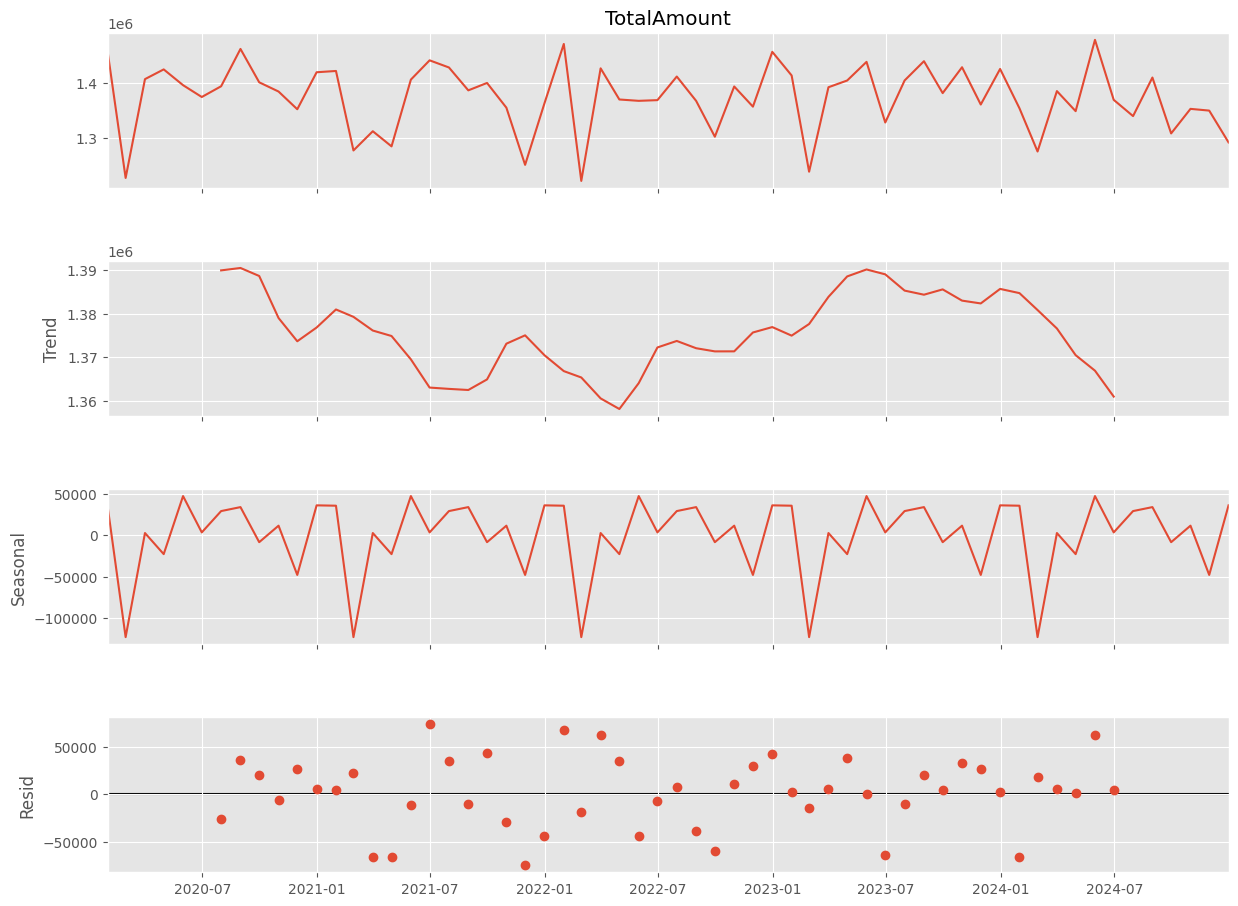

In [2]:
monthly_rev = success_orders.resample('M', on='OrderDate')['TotalAmount'].sum().to_frame()

decomposition = seasonal_decompose(monthly_rev['TotalAmount'], model='additive')
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

## 3. Customer Lifetime Value (CLV) Prediction Prep
Identifying features for CLV forecasting.

In [3]:
clv_df = success_orders.groupby('CustomerID').agg({
    'TotalAmount': 'sum',
    'OrderID': 'count',
    'Discount': 'mean',
    'ShippingCost': 'mean'
}).reset_index()

print("CLV Features Dataset:")
print(clv_df.head())

CLV Features Dataset:
   CustomerID  TotalAmount  OrderID  Discount  ShippingCost
0  CUST000002      1112.67        2  0.100000      8.920000
1  CUST000003      1116.91        1  0.150000      9.020000
2  CUST000004      2660.06        3  0.183333      6.016667
3  CUST000005      1089.56        1  0.200000      0.920000
4  CUST000006      2793.37        3  0.033333      8.900000


## 4. Forecasting Sales (Next 3 Months - Projection)
A simple moving average based projection for high-level planning.

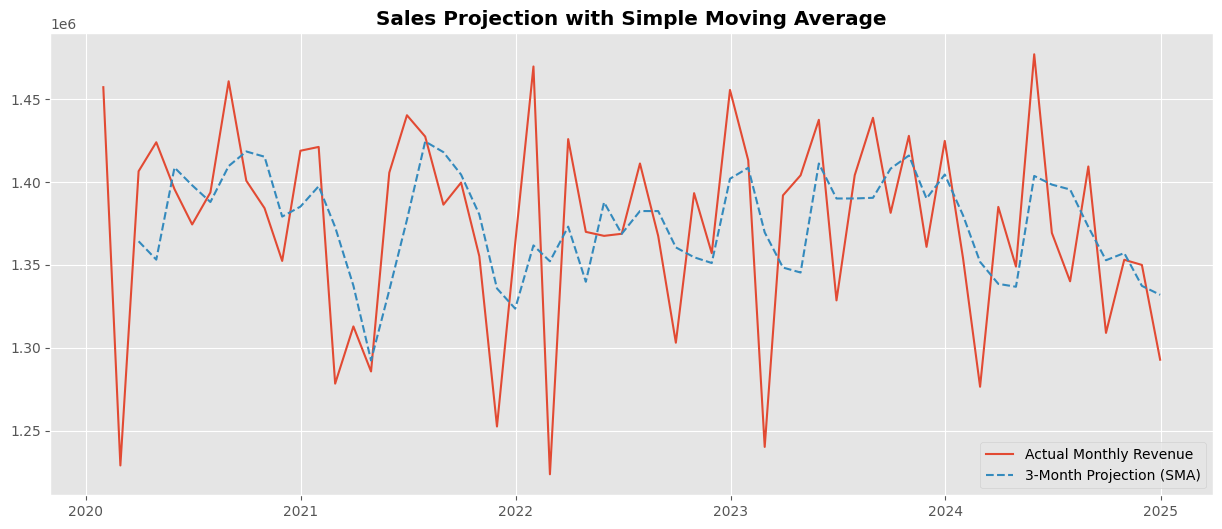

In [4]:
monthly_rev['SMA_3'] = monthly_rev['TotalAmount'].rolling(window=3).mean()
plt.figure(figsize=(15, 6))
plt.plot(monthly_rev.index, monthly_rev['TotalAmount'], label='Actual Monthly Revenue')
plt.plot(monthly_rev.index, monthly_rev['SMA_3'], label='3-Month Projection (SMA)', linestyle='--')
plt.title('Sales Projection with Simple Moving Average', fontweight='bold')
plt.legend()
plt.show()